In [263]:
import numpy as np
import pandas as pd
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV

%matplotlib inline

In [264]:
# --- Loading the train dataset
train_dataset = pd.read_csv('data/train_dataset.csv')

# --- Loading the dataset
test_dataset = pd.read_csv('data/test_dataset.csv')
    

In [265]:
# --- Defining the function that will use the model to complete the test dataset

def complete_dataset(model_name, model):

    # Loading the test dataset
    test_dataset = pd.read_csv('data/test_dataset.csv')

    # Making the predictions
    test_pred = model.predict(test_dataset)
    test_dataset['Transition'] = test_pred

    # Dropping all columns but the Transition column
    test_dataset.drop(test_dataset.columns.difference(['Transition']), axis=1, inplace=True)

    # Creating a RowId column
    test_dataset['RowId'] = np.arange(1, test_dataset.shape[0] + 1)

    # Placing the RowId column in the first position
    cols = test_dataset.columns.tolist()
    cols = cols[-1:] + cols[:-1]
    test_dataset = test_dataset[cols]

    # Transforming the Transition column back to its original values
    replace_map = {'Transition': {0: 'CN-CN', 1: 'AD-AD', 2: 'CN-MCI', 3: 'MCI-AD', 4: 'MCI-MCI'}}
    test_dataset.replace(replace_map, inplace=True)
    test_dataset.head()

    # Saving the test dataset to a csv file
    test_dataset.to_csv('test_predictions_' + model_name + '.csv', index=False)

In [266]:
# --- Defining features and target
X = train_dataset.drop('Transition', axis=1)
y = train_dataset['Transition']

In [267]:
# Dropping the oversampled column if it exists in features
if 'oversampled' in X.columns:
    X = X.drop(columns=['oversampled'])


## Random Forest

In [268]:
# --- Implementing a Random Forest model

# Defining the hyperparameter distributions
param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [2, 6, 12, 20, None]
}

# Initializing base model
base_rf = RandomForestClassifier(random_state=123)

oversampling_indicator = train_dataset['oversampled'] # will be used to guarantee that oversampled data is only used in training

# Getting indices for non-oversampled and oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index
oversampled_indices = X[oversampling_indicator == 'YES'].index

# Initializing StratifiedKFold for non-oversampled data
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Creating custom split indices that include oversampled data in training byt not in validation
custom_splits = []
for train_idx, val_idx in skf.split(
    X.loc[non_oversampled_indices], 
    y.loc[non_oversampled_indices]
):
    # Getting the actual indices from non_oversampled_indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    custom_splits.append((final_train_idx, actual_val_idx))

# Initializing RandomizedSearchCV with custom splits. This will search for the best hyperparameters
random_search = RandomizedSearchCV(
    estimator=base_rf,
    param_distributions=param_dist,
    n_iter=10,
    cv=custom_splits,
    scoring='f1_macro',
    random_state=123,
    n_jobs=-1,
    verbose=1
)

# Fitting the random search
random_search.fit(X, y)

# Getting the best model
best_rf = random_search.best_estimator_

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing final cross-validation with best model
for fold, (train_idx, val_idx) in enumerate(custom_splits):
    # Training best model on combined data (original + oversampled)
    best_rf.fit(X.loc[train_idx], y.loc[train_idx])
    
    # Predicting on validation set (non-oversampled only)
    val_pred = best_rf.predict(X.loc[val_idx])
    val_prob = best_rf.predict_proba(X.loc[val_idx])
    
    # Storing predictions
    fold_indices = np.where(non_oversampled_indices.isin(val_idx))[0]
    predictions[fold_indices] = val_pred
    probabilities[fold_indices] = val_prob

# Calculating final score
f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')

print('Random Forest Classifier Results:')
print('Best Parameters:', random_search.best_params_)
print('Best Cross-Validation Score:', random_search.best_score_)
print('Final Macro F1 Score:', f1_macro)

# Saving predictions and probabilities
np.save('rfc_predictions.npy', predictions)
np.save('rfc_probabilities.npy', probabilities)

Fitting 10 folds for each of 10 candidates, totalling 100 fits
Random Forest Classifier Results:
Best Parameters: {'n_estimators': 100, 'max_depth': 2}
Best Cross-Validation Score: 0.34983030690975886
Final Macro F1 Score: 0.3566823938200977


In [269]:
# --- Analyzing the confusion matrix

y_non_oversampled = y.loc[non_oversampled_indices]
rfc_pred = predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, rfc_pred))

Confusion matrix
[[77  3  0  5 11]
 [ 3 33  0 20  4]
 [ 7  0  0  2  1]
 [16 18  0 26  8]
 [36  8  0 16 11]]


Text(0.5, -0.1, 'Confusion matrix for Random Forest Classifier')

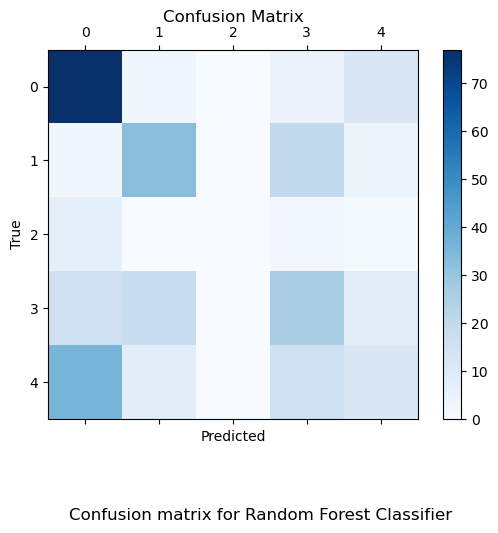

In [270]:

# --- Plotting the confusion matrix
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_non_oversampled, rfc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for Random Forest Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

In [271]:
# --- Completing the test dataset
complete_dataset('RandomForestClassifier', best_rf)

## XGBoost

In [272]:
# --- Implementing an XGBoost model

oversampling_indicator = train_dataset['oversampled']

# Initializing XGBoost with best parameters
xgbc = xgb.XGBClassifier(
    objective='multi:softprob',
    random_state=123,
    num_class=5,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05
)

# Getting indices of non-oversampled data
non_oversampled_indices = X[oversampling_indicator == 'NO'].index

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Initializing array for storing predictions
predictions = np.zeros(len(non_oversampled_indices))
probabilities = np.zeros((len(non_oversampled_indices), 5))

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(
    X.loc[non_oversampled_indices],
    y.loc[non_oversampled_indices]
)):
    # Getting the actual indices
    actual_train_idx = non_oversampled_indices[train_idx]
    actual_val_idx = non_oversampled_indices[val_idx]
    
    # Add oversampled data to training set
    oversampled_indices = X[oversampling_indicator == 'YES'].index
    final_train_idx = np.concatenate([actual_train_idx, oversampled_indices])
    
    # Training model on combined data (original + oversampled)
    xgbc.fit(
        X.loc[final_train_idx], 
        y.loc[final_train_idx],
        # Optional: add sample weights if needed
        # sample_weight=compute_sample_weights(y.loc[final_train_idx])
    )
    
    # Predicting on validation set (non-oversampled only)
    val_pred = xgbc.predict(X.loc[actual_val_idx])
    val_prob = xgbc.predict_proba(X.loc[actual_val_idx])
    
    # Storing predictions
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
# Calculating final score
f1_macro = f1_score(y.loc[non_oversampled_indices], predictions, average='macro')

print('\nFinal XGBoost Classifier')
print(f'Overall Macro F1 Score: {f1_macro:.3f}')

# Save predictions and probabilities for ensemble modeling
np.save('xgb_predictions.npy', predictions)
np.save('xgb_probabilities.npy', probabilities)


KeyboardInterrupt: 

In [ ]:
# --- Analyzing the confusion matrix

xgbc_pred = predictions

# Printing the confusion matrix
print("Confusion matrix")
print(confusion_matrix(y_non_oversampled, xgbc_pred))

Confusion matrix
[[70  4  1  8 13]
 [ 1 24  0 20 15]
 [ 5  1  0  1  3]
 [15 20  0 17 16]
 [28  8  1 23 11]]


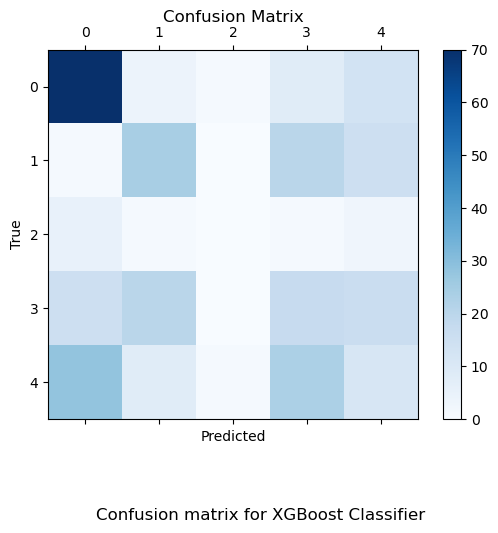

In [ ]:
# --- Plotting the confusion matrix with a caption
fig, ax = plt.subplots()
cax = ax.matshow(confusion_matrix(y_non_oversampled, xgbc_pred), cmap=plt.cm.Blues)
fig.colorbar(cax)

# Adding labels
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix', pad=20)

# Adding caption
caption = "Confusion matrix for XGBoost Classifier"
plt.figtext(0.5, -0.1, caption, wrap=True, horizontalalignment='center', fontsize=12)

plt.show()

In [ ]:
# Completing the test dataset
complete_dataset('xgboost', xgbc)

## SVM

In [ ]:
# --- SVM MODEL ---
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Initializing the SVM model with pipeline
svm = make_pipeline(
    StandardScaler(),
    SVC(
        random_state=123,
        kernel='rbf',
        class_weight='balanced',
        probability=True,
        cache_size=1000
    )
)

# Optional: Add hyperparameter tuning
param_distributions = {
    'svc__C': np.logspace(-3, 3, 7),
    'svc__gamma': ['scale', 'auto'] + list(np.logspace(-3, 3, 7))
}

svm = RandomizedSearchCV(
    svm,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=123
)

# Initializing arrays for storing predictions and probabilities
predictions = np.zeros(len(X))
probabilities = np.zeros((len(X), len(np.unique(y))))
fold_scores = []

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold + 1}/10")
    
    # Training model
    svm.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    # If using RandomizedSearchCV, print best parameters
    if isinstance(svm, RandomizedSearchCV):
        print("Best parameters for this fold:", svm.best_params_)
    
    # Predicting on validation set
    val_pred = svm.predict(X.iloc[val_idx])
    val_prob = svm.predict_proba(X.iloc[val_idx])
    
    # Storing predictions and probabilities
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
    # Calculate and store fold score
    fold_score = f1_score(y.iloc[val_idx], val_pred, average='macro')
    fold_scores.append(fold_score)
    print(f"Fold {fold + 1} Macro F1: {fold_score:.3f}")

# Calculating final scores
final_f1_macro = f1_score(y, predictions, average='macro')

print('\nFinal SVM Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')
print(f'Std Dev of Fold Scores: {np.std(fold_scores):.3f}')

print('\nConfusion Matrix:')
print(confusion_matrix(y, predictions))

# Save predictions and probabilities for ensemble modeling
np.save('svm_predictions.npy', predictions)
np.save('svm_probabilities.npy', probabilities)


Fold 1/10
Best parameters for this fold: {'svc__gamma': 'scale', 'svc__C': 1.0}
Fold 1 Macro F1: 0.291

Fold 2/10
Best parameters for this fold: {'svc__gamma': 0.1, 'svc__C': 1.0}
Fold 2 Macro F1: 0.286

Fold 3/10
Best parameters for this fold: {'svc__gamma': 0.01, 'svc__C': 1.0}
Fold 3 Macro F1: 0.316

Fold 4/10
Best parameters for this fold: {'svc__gamma': 0.1, 'svc__C': 1.0}
Fold 4 Macro F1: 0.352

Fold 5/10
Best parameters for this fold: {'svc__gamma': 0.1, 'svc__C': 1.0}
Fold 5 Macro F1: 0.361

Fold 6/10
Best parameters for this fold: {'svc__gamma': 0.1, 'svc__C': 1.0}
Fold 6 Macro F1: 0.426

Fold 7/10
Best parameters for this fold: {'svc__gamma': 0.1, 'svc__C': 1.0}
Fold 7 Macro F1: 0.312

Fold 8/10
Best parameters for this fold: {'svc__gamma': 'scale', 'svc__C': 1.0}
Fold 8 Macro F1: 0.344

Fold 9/10
Best parameters for this fold: {'svc__gamma': 0.1, 'svc__C': 1.0}
Fold 9 Macro F1: 0.352

Fold 10/10
Best parameters for this fold: {'svc__gamma': 0.1, 'svc__C': 1.0}
Fold 10 Macro

In [ ]:
# Complete the dataset
complete_dataset('svm', svm)

## Logistic Regression

In [ ]:
# --- LOGISTIC REGRESSION ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Initializing the logistic regression model with pipeline
log_reg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        random_state=123,
        max_iter=2000,
        class_weight='balanced',
        multi_class='multinomial',
        solver='saga'
    )
)

# Optional: Add hyperparameter tuning
param_distributions = {
    'logisticregression__C': np.logspace(-4, 4, 9),
    'logisticregression__penalty': ['l1', 'l2', 'elasticnet'],
    'logisticregression__l1_ratio': [0.2, 0.5, 0.9]
}

log_reg = RandomizedSearchCV(
    log_reg,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=123
)

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Initializing arrays for storing predictions and probabilities
predictions = np.zeros(len(X))
probabilities = np.zeros((len(X), len(np.unique(y))))
fold_scores = []

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold + 1}/10")
    
    # Training model
    log_reg.fit(X.iloc[train_idx], y.iloc[train_idx])
    
    # If using RandomizedSearchCV, print best parameters
    if isinstance(log_reg, RandomizedSearchCV):
        print("Best parameters for this fold:", log_reg.best_params_)
    
    # Predicting on validation set
    val_pred = log_reg.predict(X.iloc[val_idx])
    val_prob = log_reg.predict_proba(X.iloc[val_idx])
    
    # Storing predictions and probabilities
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
    # Calculate and store fold score
    fold_score = f1_score(y.iloc[val_idx], val_pred, average='macro')
    fold_scores.append(fold_score)
    print(f"Fold {fold + 1} Macro F1: {fold_score:.3f}")

# Calculating final scores
final_f1_macro = f1_score(y, predictions, average='macro')

print('\nFinal Logistic Regression Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')
print(f'Std Dev of Fold Scores: {np.std(fold_scores):.3f}')
print('\nDetailed Classification Report:')
print(classification_report(y, predictions))

print('\nConfusion Matrix:')
print(confusion_matrix(y, predictions))

# Save predictions and probabilities for ensemble modeling
np.save('logreg_predictions.npy', predictions)
np.save('logreg_probabilities.npy', probabilities)


Fold 1/10


c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters for this fold: {'logisticregression__penalty': 'l2', 'logisticregression__l1_ratio': 0.2, 'logisticregression__C': 0.01}
Fold 1 Macro F1: 0.293

Fold 2/10


c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters for this fold: {'logisticregression__penalty': 'l2', 'logisticregression__l1_ratio': 0.2, 'logisticregression__C': 1.0}
Fold 2 Macro F1: 0.167

Fold 3/10


...

c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters for this fold: {'logisticregression__penalty': 'l2', 'logisticregression__l1_ratio': 0.2, 'logisticregression__C': 1.0}
Fold 8 Macro F1: 0.237

Fold 9/10


c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best parameters for this fold: {'logisticregression__penalty': 'l2', 'logisticregression__l1_ratio': 0.2, 'logisticregression__C': 0.01}
Fold 9 Macro F1: 0.286

Fold 10/10
Best parameters for this fold: {'logisticregression__penalty': 'l2', 'logisticregression__l1_ratio': 0.2, 'logisticregression__C': 0.01}
Fold 10 Macro F1: 0.328

Final Logistic Regression Results
Overall Macro F1 Score: 0.324
Std Dev of Fold Scores: 0.082

Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.60      0.54      0.57        96
           1       0.43      0.48      0.45        60
           2       0.10      0.50      0.17        10
           3       0.30      0.29      0.30        68
           4       0.20      0.10      0.13        71

    accuracy                           0.37       305
   macro avg       0.33      0.38      0.32       305
weighted avg       0.39      0.37      0.37       305


Confusion Matrix:
[[52  3 19  7 15]
 [ 2 29  2 22

c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1197: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(
c:\Users\Utilizador\miniconda3\envs\daa\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [ ]:
# Complete the dataset
complete_dataset('logreg', log_reg)

In [ ]:
import lightgbm as lgb
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

# Initializing LightGBM with better parameters for your case
lgbm = lgb.LGBMClassifier(
    objective='multiclass',
    random_state=123,
    num_class=5,
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    class_weight='balanced',  # Handle class imbalance
    boosting_type='goss',    # Gradient-based One-Side Sampling, good for imbalanced data
    verbose=-1,              
    n_jobs=-1,              
    feature_fraction=0.8,    
    reg_alpha=0.1,          
    reg_lambda=0.1,         
    min_child_samples=20    
)

# Optional: Add hyperparameter tuning
param_distributions = {
    'n_estimators': [100, 200, 500],
    'max_depth': [3, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'feature_fraction': [0.6, 0.7, 0.9],
    'reg_alpha': [0, 0.1, 0.5, 1.0],
    'reg_lambda': [0, 0.1, 0.5, 1.0],
    'min_child_samples': [10, 20, 30, 50]
}

lgbm = RandomizedSearchCV(
    lgbm,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    random_state=123
)

# Initializing StratifiedKFold
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=123)

# Initializing arrays for storing predictions and probabilities
predictions = np.zeros(len(X))
probabilities = np.zeros((len(X), 5))  # 5 classes
fold_scores = []
feature_importance_folds = []

# Performing cross-validation
for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold + 1}/10")
    
    # Training model
    lgbm.fit(
        X.iloc[train_idx], 
        y.iloc[train_idx],
        eval_set=[(X.iloc[val_idx], y.iloc[val_idx])],
        eval_metric='multi_logloss',
    )
    
    # If using RandomizedSearchCV, print best parameters
    if isinstance(lgbm, RandomizedSearchCV):
        print("Best parameters for this fold:", lgbm.best_params_)
        model = lgbm.best_estimator_
    else:
        model = lgbm
    
    # Predicting on validation set
    val_pred = model.predict(X.iloc[val_idx])
    val_prob = model.predict_proba(X.iloc[val_idx])
    
    # Storing predictions and probabilities
    predictions[val_idx] = val_pred
    probabilities[val_idx] = val_prob
    
    # Calculate and store fold score
    fold_score = f1_score(y.iloc[val_idx], val_pred, average='macro')
    fold_scores.append(fold_score)
    print(f"Fold {fold + 1} Macro F1: {fold_score:.3f}")
    
    # Store feature importance for this fold
    if not isinstance(lgbm, RandomizedSearchCV):
        feature_importance_folds.append(model.feature_importances_)

# Calculating final scores
final_f1_macro = f1_score(y, predictions, average='macro')

print('\nFinal LightGBM Results')
print(f'Overall Macro F1 Score: {final_f1_macro:.3f}')
print(f'Std Dev of Fold Scores: {np.std(fold_scores):.3f}')
print('\nDetailed Classification Report:')
print(classification_report(y, predictions))

print('\nConfusion Matrix:')
print(confusion_matrix(y, predictions))

# Feature Importance Analysis
if not isinstance(lgbm, RandomizedSearchCV) and feature_importance_folds:
    mean_importance = np.mean(feature_importance_folds, axis=0)
    feature_importance = pd.DataFrame({
        'feature': X.columns,
        'importance': mean_importance
    })
    print("\nTop 10 Most Important Features:")
    print(feature_importance.nlargest(10, 'importance'))

# Save predictions and probabilities for ensemble modeling
np.save('lgbm_predictions.npy', predictions)
np.save('lgbm_probabilities.npy', probabilities)


Fold 1/10
Best parameters for this fold: {'reg_lambda': 0.1, 'reg_alpha': 0.5, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 3, 'learning_rate': 0.05, 'feature_fraction': 0.7}
Fold 1 Macro F1: 0.227

Fold 2/10
Best parameters for this fold: {'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 6, 'learning_rate': 0.1, 'feature_fraction': 0.7}
Fold 2 Macro F1: 0.274

Fold 3/10
Best parameters for this fold: {'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 3, 'learning_rate': 0.01, 'feature_fraction': 0.6}
Fold 3 Macro F1: 0.295

Fold 4/10
Best parameters for this fold: {'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 3, 'learning_rate': 0.01, 'feature_fraction': 0.6}
Fold 4 Macro F1: 0.454

Fold 5/10
Best parameters for this fold: {'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 100, 'min_child_samples': 20, 'max_depth': 6, 'learning_r

In [ ]:
# Complete the dataset
complete_dataset('lightgbm', lgbm)